# Проект: семантический поиск товаров по текстовому запросу

**Ваша роль.** Вы специалист по Data Science. Компания развивает онлайн-каталог товаров, и сейчас руководству кажется, что классический поиск по ключевым словам плохо справляется с реальными запросами. Пользователи пишут названия с ошибками, кириллицей, используют просторечные слова, ищут товары по назначению, а не по функциональности («удобные кроссовки для бега» вместо «мужские спортивные кроссовки с амортизацией»). Команда хочет проверить, поможет ли векторный поиск улучшить качество поисковой системы.

**Задача.** Вам нужно построить MVP системы семантического поиска, сравнить его с лексической baseline-моделью на подготовленной разметке и дать бизнесу обоснованную рекомендацию о том, где новое решение помогает, где ошибается и стоит ли его вообще внедрять.

## Данные

| Файл | Что это | Когда нужен |
|---|---|---|
| wb_products_raw_sample.parquet | Исходный каталог, ~200 тысяч строк, все категории. <br> Вам нужно самостоятельно отобрать рабочее подмножество этих данных | Недели 1–2 |
| wb_products_dedup.parquet | Пул асессоров: множество товаров, по которому делалась разметка | Неделя 2, раздел 4 |
| queries_synthetic_train.parquet | Разметка релевантности, train | Недели 2–3 |
| queries_synthetic_test.parquet | Разметка релевантности, test | **один прогон** в конце недели 3 |

Файлы с разметкой содержат четыре столбца: `query_id`, `query_text`, `item_id`, `relevance`. Шкала в `relevance` от `0` до `3`, где `0` — товар нерелевантен, а `3` — максимально релевантен. Связь с каталогом: `item_id` ↔ `imt_id`.

In [1]:
# Импорты

import pandas as pd
import numpy as np
import random

import matplotlib.pyplot as plt
import seaborn as sns

from dotenv import load_dotenv
import os

import pyarrow
import s3fs

from collections import Counter

import re
import html

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

import torch
from pathlib import Path
from sentence_transformers import SentenceTransformer

import time

/Users/mishamishin/Desktop/DataScience/Практикум/Проекты/Мастерская/semantic-search-mvp/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Фиксируем сид

R_S = 42

np.random.seed(R_S)
random.seed(R_S)

In [3]:
# Креды и адреса

load_dotenv()

S3_ACC_KEY = os.getenv('S3_ACCESS_KEY_ID')
S3_SECRET_KEY = os.getenv('S3_SECRET_KEY')
S3_BUCKET = os.getenv('S3_BUCKET')

ENDPOINT = 'https://storage.yandexcloud.net'

# Необходимые файлы

RAW_PRODUCTS_PATH = "wb_products_raw_sample.parquet"
ASSESSED_POOL_PATH = "wb_products_dedup.parquet"
TRAIN_QUERIES_PATH = "queries_synthetic_train.parquet"
TEST_QUERIES_PATH = "queries_synthetic_test.parquet"

if not all([S3_ACC_KEY, S3_SECRET_KEY, S3_BUCKET]):
    raise ValueError(
        "Не найдены S3_ACCESS_KEY_ID, S3_SECRET_KEY или S3_BUCKET в .env"
    )

---

## Неделя 1 — знакомство с данными и EDA

**Цель** — понять, с какими данными работаете, чтобы принять обоснованные решения:

- выбрать категории, с которыми будете работать;
- определить, как будете очищать описания от всего лишнего;
- решить, из каких полей собирать текст товара.

**Главный критерий успеха:** любое ваше решение по данным вы можете подкрепить ссылкой на конкретные результаты анализа.

### 1. Загрузка данных

Загрузите каталог и обе разметки. Изучите их структуру: проанализируйте колонки и типы данных в них, определите, что описывает одна строка.

**Подсказка.** `imt_id` — карточка товара, `nm_id` — конкретный артикул этого товара, то есть его разновидность, отличающаяся цветом, размером или чем-то ещё. Определите, что из этого должен возвращать поиск, — от этого зависит, на каком уровне вы будете строить индекс.

In [ ]:
fs = s3fs.S3FileSystem(
    key=S3_ACC_KEY,
    secret=S3_SECRET_KEY,
    endpoint_url=ENDPOINT
)

df_raw = pd.read_parquet(
    's3://{}/{}'.format(S3_BUCKET, RAW_PRODUCTS_PATH),
    filesystem=fs,
    engine='pyarrow'
    )
queries_train = pd.read_parquet(
    's3://{}/{}'.format(S3_BUCKET, TRAIN_QUERIES_PATH),
    filesystem=fs,
    engine='pyarrow'
    )
queries_test = pd.read_parquet(
    's3://{}/{}'.format(S3_BUCKET, TEST_QUERIES_PATH),
    filesystem=fs,
    engine='pyarrow'
    )

#### Исходный каталог товаров (wb_products_raw_sample)

In [5]:
def df_info(df, name):
    print(f'Размеры датасета {name}:', df.shape)
    print()

    df.info()
    print()

    print('Статистики:')
    display(df.describe(include='all'))
    print()

    print('Несколько первых строк:')
    display(df.head())

    print('Пропуски:')
    missings = df.isna().sum().to_frame()
    missings.columns = ['Кол-во']
    missings['Процент'] = (missings['Кол-во'] / df.shape[0] * 100).round(3)
    display(missings)
    print()

    print('Количество полных дубликатов строк:', df.duplicated().sum())

df_info(df_raw, 'Исходный каталог товаров (wb_products_raw_sample)')

Размеры датасета Исходный каталог товаров (wb_products_raw_sample): (200000, 9)

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype
---  ------           --------------   -----
 0   imt_id           200000 non-null  int64
 1   nm_id            200000 non-null  int64
 2   imt_name         200000 non-null  str  
 3   subj_name        200000 non-null  str  
 4   subj_root_name   200000 non-null  str  
 5   nm_colors_names  200000 non-null  str  
 6   vendor_code      200000 non-null  str  
 7   description      200000 non-null  str  
 8   brand_name       200000 non-null  str  
dtypes: int64(2), str(7)
memory usage: 169.5 MB

Статистики:


,imt_id,nm_id,imt_name,subj_name,subj_root_name,nm_colors_names,vendor_code,description,brand_name
count,2.000000e+05,2.000000e+05,200000,200000,200000,200000,200000,200000,200000
unique,NaN,NaN,104046,3234,65,9647,191340,88801,13319
top,NaN,NaN,Платье,Платья,Одежда,,,,Airline
freq,NaN,NaN,4703,6998,43316,34226,6646,57500,2691
mean,9.313147e+06,1.209294e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,5.428525e+06,3.880015e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000e+05,1.074950e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,1.002833e+07,1.338821e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1.007894e+07,1.345970e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.013513e+07,1.353642e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Несколько первых строк:


,imt_id,nm_id,imt_name,subj_name,subj_root_name,nm_colors_names,vendor_code,description,brand_name
0,100000,118982,Сумка,Сумки,Аксессуары,бежевый,82992/beige,,Pola
1,1000000,1206857,Шапка,Шапки,Головные уборы,белый,Лаки/белый,,Ваша Шляпка
2,1000000,1206860,Шапка,Шапки,Головные уборы,черный,Лаки/черный,,Ваша Шляпка
3,10000000,13349975,Очки TRUESPIN Fold,Солнцезащитные очки,Аксессуары,черный,20S.Y.T.35.00.564/Black/Black,,True Spin
4,10000001,13349981,Очки TRUESPIN Candor,Солнцезащитные очки,Аксессуары,черный,20S.Y.T.35.00.567/Black,,True Spin


Пропуски:


,Кол-во,Процент
imt_id,0,0.0
nm_id,0,0.0
imt_name,0,0.0
subj_name,0,0.0
subj_root_name,0,0.0
nm_colors_names,0,0.0
vendor_code,0,0.0
description,0,0.0
brand_name,0,0.0



Количество полных дубликатов строк: 0


Всего в датасете `wb_products_raw_sample` 200 000 строк и 9 полей. Все значения строковые за исключением полей с id товара и артикула.

В датасете не обнаружено ни явных пропусков (NaN), ни полных дубликатов строк. Однако уже сейчас видно, что в полях `nm_colors_names`, `vendor_code` и `description` **присутствует много пустых строк**. Подробнее разберем этот вопрос на этапе EDA.

#### Тренировочная выборка (queries_synthetic_train)

In [6]:
df_info(queries_train, 'Тренировочная выборка (queries_synthetic_train)')

Размеры датасета Тренировочная выборка (queries_synthetic_train): (11453, 4)

<class 'pandas.DataFrame'>
RangeIndex: 11453 entries, 0 to 11452
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   query_id    11453 non-null  str  
 1   query_text  11453 non-null  str  
 2   item_id     11453 non-null  int64
 3   relevance   11453 non-null  int64
dtypes: int64(2), str(2)
memory usage: 854.8 KB

Статистики:


,query_id,query_text,item_id,relevance
count,11453,11453,1.145300e+04,11453.000000
unique,700,700,NaN,NaN
top,SYN_000366,хлопковые футболки,NaN,NaN
freq,31,31,NaN,NaN
mean,NaN,NaN,8.814082e+06,1.218371
std,NaN,NaN,3.457068e+06,0.541248
min,NaN,NaN,1.000370e+05,1.000000
25%,NaN,NaN,1.001999e+07,1.000000
50%,NaN,NaN,1.007633e+07,1.000000
75%,NaN,NaN,1.013258e+07,1.000000



Несколько первых строк:


,query_id,query_text,item_id,relevance
0,SYN_000001,жилеты на пуговицах,100211,3
1,SYN_000001,жилеты на пуговицах,100433,1
2,SYN_000001,жилеты на пуговицах,1000988,1
3,SYN_000001,жилеты на пуговицах,1016032,1
4,SYN_000001,жилеты на пуговицах,10001023,1


Пропуски:


,Кол-во,Процент
query_id,0,0.0
query_text,0,0.0
item_id,0,0.0
relevance,0,0.0



Количество полных дубликатов строк: 0


Всего в датасете `queries_synthetic_train` 11 453 строки и 4 поля. Текст и id запроса представлены текстовыми полями, а id айтема и оценка - числовыми.

Уникальных запросов в датасете всего 700. Видимо, один и тот же запрс оценивался для нескольких товаров.

Явных пропусков и полных дубликатов в датасете не найдено.

Посчитаем количество айтемов на один запрос и распределение оценок.

In [7]:
it_for_q_train = queries_train.groupby('query_id')['item_id'].nunique().mean()
print('Количество оценненных товаров на один запрос:', round(it_for_q_train))

rate_dist_train = queries_train['relevance'].value_counts().to_frame()
rate_dist_train.columns = ['count']
rate_dist_train['perc'] = rate_dist_train['count'] / queries_train.shape[0] * 100

print()
print('Распределение оценок релевантности:')
rate_dist_train.round()

Количество оценненных товаров на один запрос: 16

Распределение оценок релевантности:


,count,perc
relevance,,
1,9652,84.0
2,1101,10.0
3,700,6.0


Судя по распределению оценок, максимально релевантный товар (с оценкой `3`) для каждого из 700 запросов только один, остальные чаще всего оцениваются минимальным значением `1`, а около 10% датасета получили оценку `2`.

Проверим несколько текстов запросов.

In [8]:
cnt = 0
print('Нерелевантные товары (оценка 1):')
while cnt < 5:
    idx = random.randint(0, queries_train.shape[0])
    if queries_train['relevance'].loc[idx] == 1:
        print('Запрос:', queries_train['query_text'].loc[idx])
        print('Товар:', df_raw[df_raw['imt_id'] == queries_train['item_id'].loc[idx]]['imt_name'].to_list()[0])
        print('Описание:', df_raw[df_raw['imt_id'] == queries_train['item_id'].loc[idx]]['description'].to_list()[0])
        print('-')
        cnt += 1

print()
cnt = 0
print('Релевантные товары (оценка 3):')
while cnt < 5:
    idx = random.randint(0, queries_train.shape[0])
    if queries_train['relevance'].loc[idx] == 3:
        print('Запрос:', queries_train['query_text'].loc[idx])
        print('Товар:', df_raw[df_raw['imt_id'] == queries_train['item_id'].loc[idx]]['imt_name'].to_list()[0])
        print('Описание:', df_raw[df_raw['imt_id'] == queries_train['item_id'].loc[idx]]['description'].to_list()[0])
        print('-')
        cnt += 1

Нерелевантные товары (оценка 1):
Запрос: футболки puma
Товар: Футболка - EUDOR
Описание: 
-
Запрос: комбинезоны на молнии
Товар: Комбинезон "Скарлет" (красный)
Описание: 
-
Запрос: лонгсливы broadway
Товар: Лонгслив Спорт
Описание: 
-
Запрос: удобные босоножки
Товар: Босоножки Genuin Vivier 0811-36
Описание: 
-
Запрос: хлопковые футболки поло на пуговицах
Товар: Поло - REA
Описание: 
-

Релевантные товары (оценка 3):
Запрос: водолазки трикотажная
Товар: Водолазка трикотажная
Описание: Трикотажный джемпер-водолазка для девочек. Ворот, рукава и низ джемпера обработаны оверлоком, что создаёт эффект "волны". Удобный, повседневный предмет в гардеробе маленькой модницы. Дорогие мамочки, бадлон маломерит , смотрите таблицу размеров!
-
Запрос: угги из овчины monqi
Товар: Угги
Описание: Стильные и удобные угги, выполненные из однотонного материала. Плоская рельефная подошва препятствует скольжению. Отличная обувь для холодного сезона. Материал подкладки: 100% натуральная новозеладская овчина.
-

Неочевидно чем отличаются релевантные запросы от релевантных.

#### Тестовая выборка (queries_synthetic_test)

In [9]:
df_info(queries_test, 'Тестовая выборка (queries_synthetic_test)')

it_for_q_test = queries_test.groupby('query_id')['item_id'].nunique().mean()
print('Количество оценненных товаров на один запрос:', round(it_for_q_test))

rate_dist = queries_test['relevance'].value_counts().to_frame()
rate_dist.columns = ['count']
rate_dist['perc'] = rate_dist['count'] / queries_test.shape[0] * 100

print()
print('Распределение оценок релевантности:')
rate_dist.round()

Размеры датасета Тестовая выборка (queries_synthetic_test): (4866, 4)

<class 'pandas.DataFrame'>
RangeIndex: 4866 entries, 0 to 4865
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   query_id    4866 non-null   str  
 1   query_text  4866 non-null   str  
 2   item_id     4866 non-null   int64
 3   relevance   4866 non-null   int64
dtypes: int64(2), str(2)
memory usage: 363.5 KB

Статистики:


,query_id,query_text,item_id,relevance
count,4866,4866,4.866000e+03,4866.000000
unique,300,300,NaN,NaN
top,SYN_000424,свободные платья,NaN,NaN
freq,31,31,NaN,NaN
mean,NaN,NaN,8.857696e+06,1.201397
std,NaN,NaN,3.168832e+06,0.533104
min,NaN,NaN,1.000370e+05,1.000000
25%,NaN,NaN,1.002133e+07,1.000000
50%,NaN,NaN,1.007391e+07,1.000000
75%,NaN,NaN,1.012887e+07,1.000000



Несколько первых строк:


,query_id,query_text,item_id,relevance
0,SYN_000003,кардиганы на пуговицах,1000028,1
1,SYN_000003,кардиганы на пуговицах,1000628,3
2,SYN_000003,кардиганы на пуговицах,1008849,2
3,SYN_000003,кардиганы на пуговицах,10002779,1
4,SYN_000003,кардиганы на пуговицах,10007028,2


Пропуски:


,Кол-во,Процент
query_id,0,0.0
query_text,0,0.0
item_id,0,0.0
relevance,0,0.0



Количество полных дубликатов строк: 0
Количество оценненных товаров на один запрос: 16

Распределение оценок релевантности:


,count,perc
relevance,,
1,4186,86.0
2,380,8.0
3,300,6.0


Всего в датасете `queries_synthetic_test` 4 865 строки и 4 поля. Уникальных запросов всего 300.

В остальном (структура, пропуски, дубликаты, распределение оценок) тестовый датасет аналогичен обучающему.

**Проверьте связность данных:** все ли `item_id` из разметки есть в каталоге, нет ли пересечения `query_id` между `train` и `test`.

#### Проверка связности данных

Проверим нет ли пересечения `query_id` между обучающей и тестовой выборками.

In [10]:
intersection = set(queries_test['query_id']) & set(queries_train['query_id'])
print('Количество пересекающихся `query_id` в тестовой и обучающей выборках:', len(intersection))
assert len(intersection) == 0, f'Утечка данных! Количество пересечений: {len(intersection)}'

Количество пересекающихся `query_id` в тестовой и обучающей выборках: 0


Пересечений `query_id` между двумя выборками нет - разделение верное.

Проверим все ли `item_id` из разметки есть в каталоге.

In [11]:
catalog_id_set = set(df_raw['imt_id'])

for df, name in [(queries_train, 'train'), (queries_test, 'test'),]:
    df_id_set = set(df['item_id'])
    intersec = catalog_id_set & df_id_set

    print(f'Количество уникальных `item_id` в {name} выборке:', len(df_id_set))
    print('Из них присутствуют в каталоге:', len(intersec))
    print('Разница:', len(df_id_set) - len(intersec))
    print('-' * 10)


Количество уникальных `item_id` в train выборке: 2285
Из них присутствуют в каталоге: 2285
Разница: 0
----------
Количество уникальных `item_id` в test выборке: 1672
Из них присутствуют в каталоге: 1672
Разница: 0
----------


Все айтемы из обучающей и тестовой выборок имеются в каталоге.

### 2. EDA

#### Общий обзор данных и оценка их объёма

Посчитаем количество строк, число уникальных imt_id и nm_id, проверим данные на наличие дубликатов.

In [12]:
print('Количество строк в каталоге:', df_raw.shape[0])
print('Количество уникальных идентификаторов карточек `imt_id`:', df_raw['imt_id'].nunique())
print('Количество уникальных идентификаторов артикулов `nm_id`:', df_raw['nm_id'].nunique())
print('Количество дубликатов пар `imt_id`, `nm_id`:', df_raw.duplicated(subset=['imt_id', 'nm_id']).sum())

Количество строк в каталоге: 200000
Количество уникальных идентификаторов карточек `imt_id`: 174427
Количество уникальных идентификаторов артикулов `nm_id`: 199957
Количество дубликатов пар `imt_id`, `nm_id`: 43


Имеем 43 дубля пар `imt_id`, `nm_id`. Уникальных `nm_id` 199 957 штуки, значит ни один из дублирующихся `nm_id` не принадлежит разным `imt_id`.

Такие дубликаты удалять пока не будем так как нам все равно придется агрегировать данные по `imt_id`.

#### Полнота полей

Оценим долю пропусков в текстовых полях.

In [13]:
missings = df_raw.select_dtypes(include='str').eq('').sum().to_frame()
missings.columns = ['Count']
missings['Perc'] = (missings['Count'] / df_raw.shape[0] * 100).round(2)

print('Количество пропусков в текстовых полях:')
display(missings)

print('Количество строк с одновременно отсутствующими названием и описанием:', end=' ')
print(df_raw[['imt_name', 'description']].eq('').all(axis=1).sum())

Количество пропусков в текстовых полях:


,Count,Perc
imt_name,708,0.35
subj_name,8,0.00
subj_root_name,8,0.00
nm_colors_names,34226,17.11
vendor_code,6646,3.32
description,57500,28.75
brand_name,201,0.10


Количество строк с одновременно отсутствующими названием и описанием: 163


**Товаров без названия оказалось 708 штук (около 0.35%)** из которых 163 не имеют описания - то есть семантический поиск для них едва ли возможен, но, возможно, они могут пригодиться, например для fallback по категории.

**Без описания почти 30% товаров.** Удалять такое большое количество товаров из каталога было бы неправильным. Можно оставить добавив метку отсутствия описания.

#### Распределение по категориям

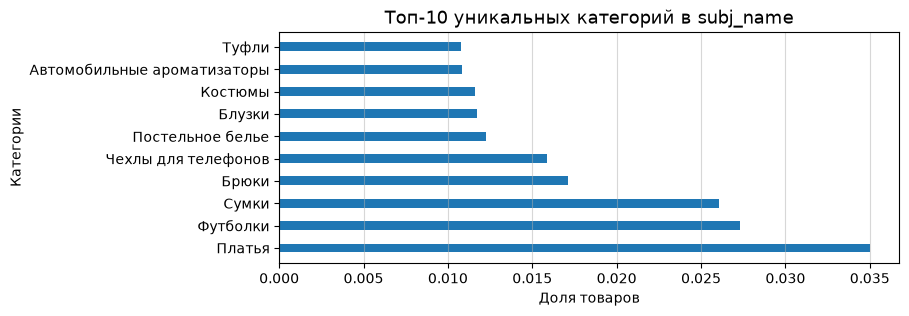

Всего уникальных значений в поле `subj_name`: 3234
Доля товаров, которая приходится на топ-10 категорий: 12.14%
5 самых редких категорий в поле subj_name:
    Ведерки детские - 0.0005%
    Карнавальные парики - 0.0005%
    Средства профилактики - 0.0005%
    Гладильные системы - 0.0005%
    Стиральные машины активаторного типа - 0.0005%
--------------------------------------------------


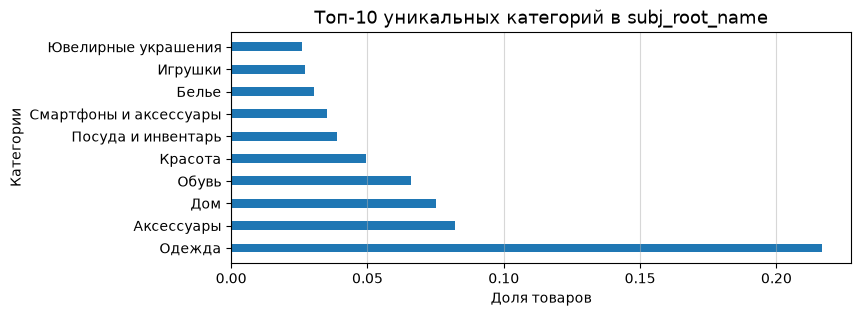

Всего уникальных значений в поле `subj_root_name`: 65
Доля товаров, которая приходится на топ-10 категорий: 48.93%
5 самых редких категорий в поле subj_root_name:
    Игровые консоли и игры - 0.0335%
    Электротранспорт - 0.0235%
    Торговое оборудование - 0.0105%
    Сетевое оборудование - 0.0105%
    missing - 0.004%
--------------------------------------------------


In [14]:
k = 10

for col in ['subj_name', 'subj_root_name']:
    counts = df_raw[col].value_counts(normalize=True)

    plt.figure(figsize=(8, 3))
    plt.barh(counts.head(k).index, counts.head(k), height=.4)

    plt.xlabel('Доля товаров')
    plt.ylabel('Категории')
    plt.title(f'Топ-{k} уникальных категорий в {col}', size=13)
    plt.grid(axis='x', alpha=.5)
    plt.show()

    print(f'Всего уникальных значений в поле `{col}`:', len(counts))
    print(f'Доля товаров, которая приходится на топ-{k} категорий: ',
          round(counts.head().sum() * 100, 2), '%', sep='')
    print(f'5 самых редких категорий в поле {col}:')
    for c in counts.tail().index:
        print(f'    {c if c else 'missing'} - {counts[c] * 100}%')
    print('-' * 50)

Проверим какие категории есть в тренирововчной выборке.

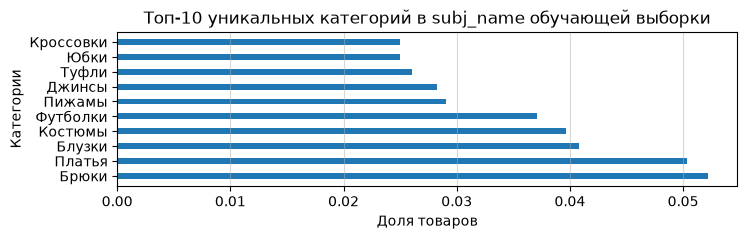

Всего уникальных значений в поле `subj_name`: 89
Доля товаров, которая приходится на топ-10 категорий: 22.01%


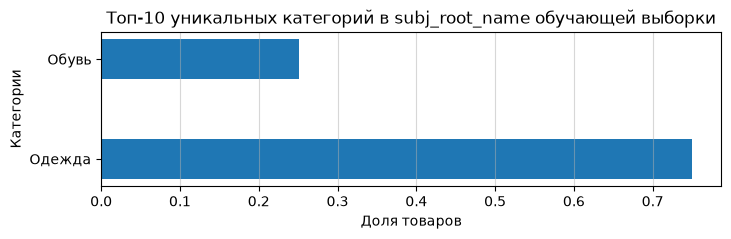

Всего уникальных значений в поле `subj_root_name`: 2
Доля товаров, которая приходится на топ-10 категорий: 100.0%


In [15]:
ids_in_train = queries_train['item_id']

for col in ['subj_name', 'subj_root_name']:
    counts = df_raw[df_raw['imt_id'].isin(ids_in_train)][col].value_counts(normalize=True)

    plt.figure(figsize=(8, 2))
    plt.barh(counts.head(k).index, counts.head(k), height=.4)

    plt.xlabel('Доля товаров')
    plt.ylabel('Категории')
    plt.title(f'Топ-{k} уникальных категорий в {col} обучающей выборки')
    plt.grid(axis='x', alpha=.5)
    plt.show()

    print(f'Всего уникальных значений в поле `{col}`:', len(counts))
    print(f'Доля товаров, которая приходится на топ-{k} категорий: ',
          round(counts.head().sum() * 100, 2), '%', sep='')

Топ категорий из каталога:
- Одежда
- Аксессуары
- Дом
- Обувь
- Красота

Всего уникальных категорий в каталоге 65.  
**На топ-10 категорий из каталога 48.93%** - то есть почти половина.
Однако, в обучающей выборке присутствуют только категории Одежда и Обувь. Поэтому обучение будет ограничено этит двумя категориями.

#### Длина текстовых полей

##### Описание товара

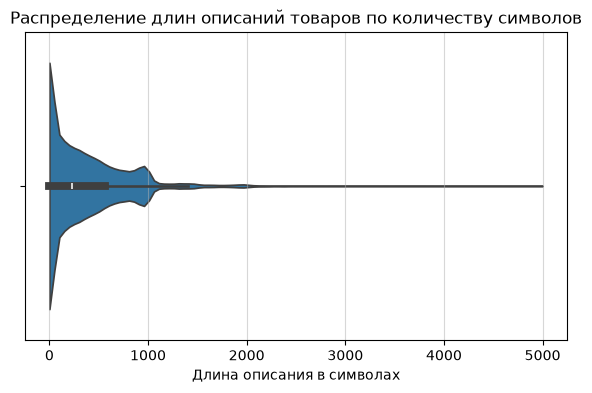

Статистики распределения длин слов:


,simbols_count
count,200000.0
mean,372.4
std,474.6
min,0.0
25%,0.0
50%,227.0
75%,563.0
max,5000.0


95 процентиль по количеству символов: 1082.0


In [16]:
simbols_count = df_raw['description'].str.len()
simbols_count.name = 'simbols_count'

plt.figure(figsize=(7, 4))
sns.violinplot(simbols_count, orient='h', cut=0)  # type: ignore

plt.title('Распределение длин описаний товаров по количеству символов')
plt.xlabel('Длина описания в символах')
plt.grid(axis='x', alpha=.5)

plt.show()

print('Статистики распределения длин слов:')
display(simbols_count.describe().round(1).to_frame())

print('95 процентиль по количеству символов:', simbols_count.quantile(.95))

Большая часть описаний имеет длину символов в диапазоне от 0 до 1000.

Медианная длина - 227, средняя - 372.

**Встречаются выборы вплоть до 5000 символов.** Посмотрим что это за такие описания:

In [17]:
for d in df_raw[simbols_count == 5000]['description'].head():
    print(d)

Милые наши покупательницы! Мы от души благодарим Вас за долгие годы верности нашему бренду! И с удовольствием дарим вам более 60% ассортимента по ценам ниже себестоимости. Для того, чтобы каждая из вас почувствовала нашу заботу и благодарность! Наши новинки и много чего интересного вы можете найти на нашем бренде Полное счастье.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

У таких описаний тысячи пробелов c точкой в самом конце. Среди них встречаются малоинформативные тексты с рекламными сообщениями.

Проверим количество слов в предложениях.

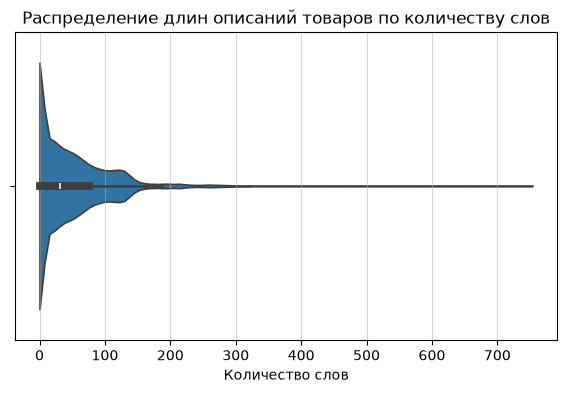

Статистики распределения количества слов:


,words_count
count,200000.0
mean,50.4
std,64.6
min,0.0
25%,0.0
50%,31.0
75%,75.0
max,754.0


95 процентиль по количеству слов: 152.0


In [18]:
words_count = df_raw['description'].str.split().str.len()
words_count.name = 'words_count'

plt.figure(figsize=(7, 4))
sns.violinplot(words_count, orient='h', cut=0)

plt.title('Распределение длин описаний товаров по количеству слов')
plt.xlabel('Количество слов')
plt.grid(axis='x', alpha=.5)

plt.show()

print('Статистики распределения количества слов:')
display(words_count.describe().round(1).to_frame())

print('95 процентиль по количеству слов:', words_count.quantile(.95))

Большая часть описаний имеет от 0 до 200 слов. Встречаются редкие описания длиной более 700 слов.

95% описаний имеют не более 152 слов. Значит, что можно ограничить описание 150 - 300 словами или 1000 символами.

Проверим несколько случайных описаний:

In [19]:
cnt = 0

while cnt < 20:
    idx = random.randint(0, df_raw.shape[0] - 1)
    if df_raw['description'].loc[idx] and df_raw['subj_root_name'].loc[idx] in ('Одежда', 'Обувь'):
        print(idx, '-', df_raw['imt_name'].loc[idx])
        print(df_raw['description'].loc[idx])
        print('-')
        cnt += 1

54921 - Ботинки
Эти непромокаемые зимние ботинки в классическом стиле прекрасно защищают ноги от холода и снега. Подошва отличается максимальным сцеплением и долговечностью, а благодаря запатентованной технологии Geox она ещё и дышит, непозволяя влаге проникнуть внутрь.

Подкладка и практичная съемная стелька из гигиеничного материала утеплены. Застежка на два ремешка с липучкой позволяет легко надевать обувь и регулировать плотность посадки.
-
175682 - Блузка для девочки
Стильная блузка с коротким рукавом. Рукава отделаны декоративным кружевом и фатином. Под горловиной на передней полочке небольшая брошь. Благодаря высокому содержанию хлопка ребенку будет комфортно при любой погоде, а добавление лайкры позволяет блузке держать форму и защищает от заломов при носке.
-
179187 - Валенсия ,вечерний комбинизон
Вечерний комбинезон, выполнен из ткани с напылением, на груди запах, застежка молния, брюки прямые, длинный рукав, в обтяжку.
-
121178 - Ночная сорочка
Женственная модель  выполнена 

HTML теги в данных описаниях не встретились. В целом описания довольно ифнформативные, но есть символы (вроде переносов строк, дефисов и знаков препинания), которые следует убрать.

Во многих описаниях указывается бренд, поэтому нет необходимости добавлять данные из отдельного поля `brand_name`.

##### Название товара

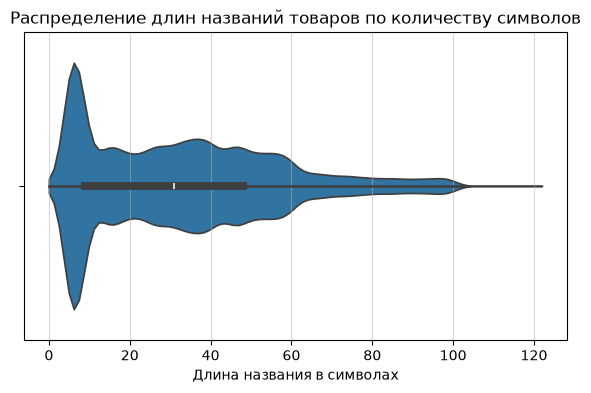

Статистики распределения длин названий товаров:


,simbols_count
count,200000.0
mean,32.9
std,24.0
min,0.0
25%,9.0
50%,31.0
75%,48.0
max,122.0


95 процентиль по количеству символов: 80.0


In [20]:
simbols_count_n = df_raw['imt_name'].str.len()
simbols_count_n.name = 'simbols_count'

plt.figure(figsize=(7, 4))
sns.violinplot(simbols_count_n, orient='h', cut=0)  # type: ignore

plt.title('Распределение длин названий товаров по количеству символов')
plt.xlabel('Длина названия в символах')
plt.grid(axis='x', alpha=.5)

plt.show()

print('Статистики распределения длин названий товаров:')
display(simbols_count_n.describe().round(1).to_frame())

print('95 процентиль по количеству символов:', simbols_count_n.quantile(.95))

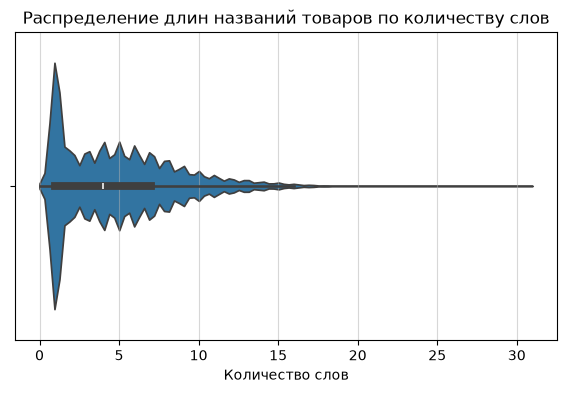

Статистики распределения количества слов:


,words_count
count,200000.0
mean,4.8
std,3.6
min,0.0
25%,1.0
50%,4.0
75%,7.0
max,31.0


95 процентиль по количеству слов: 12.0


In [21]:
words_count_n = df_raw['imt_name'].str.split().str.len()
words_count_n.name = 'words_count'

plt.figure(figsize=(7, 4))
sns.violinplot(words_count_n, orient='h', cut=0)

plt.title('Распределение длин названий товаров по количеству слов')
plt.xlabel('Количество слов')
plt.grid(axis='x', alpha=.5)

plt.show()

print('Статистики распределения количества слов:')
display(words_count_n.describe().round(1).to_frame())

print('95 процентиль по количеству слов:', words_count_n.quantile(.95))

Большая часть наименований товаров состоит из 0 - 100 символов и 0 - 15 слов.

Выбросов практически нет: только небольшое количество наименований состоящих из 15+ слов.

Наименование товаров можно никак не усекать, но при необходимости можно оставить 80-100 символов, или 15 словами.

#### Формирование текста товара для эмбеддинга

Пока определены три поля, которые будут добавлены в текст для эмбеддинга:
- `imt_name`
- `description`
- `subj_root_name`

Нет необходимости включать бренд, так как он часто встречается в описании, поэтому сейчас просто зафиксируем количество уникальных брендов из каталога.

In [22]:
print('Количество уникальных брендов:', df_raw['brand_name'].unique().shape[0])

Количество уникальных брендов: 13319


Проверим как часто цвет из `nm_colors_names` уже упомянут в названии товара

In [23]:
color_in_name = has_color = 0

for name, colors in zip(df_raw['imt_name'], df_raw['nm_colors_names']):
    endings = ("ый", "ий", "ая", "яя", "ое", "ее", "ые", "ие")

    if colors.strip():
        has_color += 1
        name = name.lower()
        if any(f'{c[:-2] if c.endswith(endings) else c}' in name for c in colors.lower().split(', ')):
            # последние два символа убираем для того, чтобы была возможность искать слова с другим окончанием
            color_in_name += 1

print(f'Всего наименований товаров, включающих цвет: {color_in_name} или {color_in_name / has_color * 100:.1f}%')


Всего наименований товаров, включающих цвет: 8186 или 4.9%


Всего 5% товаров имеют в нименовании цвет поэтому можно включить цвета из поля `nm_colors_names` в `product_text`.

---

## Неделя 2 — базовый пайплайн и оценка качества

**Цель:** оперевшись на результаты EDA, создать работающий поиск и получить первые метрики качества.

Прежде чем реализовывать семантический поиск, основанный на эмбеддингах, нужно проверить, как справляется более простая модель, опирающаяся на TF-IDF. Простая модель нужна как baseline, без этой точки отсчёта результат невозможно интерпретировать.


### 1. Подготовка данных


Реализуйте решения недели 1:

1. Отфильтруйте выбранные категории.
2. Дедуплицируйте строки по `imt_id`. Сформулируйте правило, по которому будете определять, какую строку оставить. К примеру, можете оставить строку с самым информативным описанием. Ответ обоснуйте.
3. Отбросьте карточки, у которых пусты одновременно и `imt_name`, и `description`.
4. Напишите функцию очистки текста.
5. Соберите единый текст карточек в отдельной колонке `product_text`.

#### Отбор подмножества данных

Оставим в датасете `wb_products_raw_sample` только две категории, которые есть в тренировочном датасете с запросами:
- Одежда
- Обувь

In [24]:
df_raw = df_raw[df_raw['subj_root_name'].str.lower().isin(['одежда', 'обувь'])].reset_index(drop=True)

print('Количество оставшихся строк:', df_raw.shape[0])

Количество оставшихся строк: 56503


#### Дедупликация по imt_id

Оставим по одной строке на уникальный `imt_id`. Предварительно соберем все уникальные цвета товаров в отдельную серию, а затем объединим данные.

In [25]:
def unify_colors(colors_series, top_n=5):
    colors = Counter()
    for s in colors_series:
        colors.update(c.strip().lower() for c in s.split(', ') if c.strip())

    return ', '.join(sorted(col for col, _ in colors.most_common(top_n)))

# Серия с цветами товаров
colors_u = df_raw.groupby('imt_id')['nm_colors_names'].agg(unify_colors).rename('nm_colors_names_agg')

# Считаем длины описаний
desc_lens = df_raw['description'].str.len()

# Для каждого imt_id находим индекс строки с самым длинным описанием
best_idx = desc_lens.groupby(df_raw['imt_id']).idxmax()

# Для каждого imt_id оставляем одну строку с самым длинным описанием
df_agg = df_raw.loc[best_idx].reset_index(drop=True)

# Объединяем полученный датасет с данным о цвете товаров
df_agg = df_agg.merge(colors_u, how='left', on='imt_id')

df_agg['nm_colors_names'] = df_agg['nm_colors_names_agg']
df_agg = df_agg.drop(columns='nm_colors_names_agg')

print('Количество уникальных imt_id до дедупликации:', df_raw['imt_id'].nunique())
print('Количество строк в полученном датафрейме:', df_agg.shape[0])

Количество уникальных imt_id до дедупликации: 48489
Количество строк в полученном датафрейме: 48489


#### Отсев карточек без текста

Отбросим товары, у которых одновременно не заполнены оба поля - `imt_name` и `description`.

In [26]:
df_agg = df_agg[(df_agg['imt_name'] != '') | (df_agg['description'] != '')].reset_index(drop=True)
print('Количество оставшихся строк:', df_agg.shape[0])

Количество оставшихся строк: 48376


#### Очистка текста и сборка product_text

Напишем функцию для очистки текстовых полей.

In [27]:
def clean_text(text):
    if not isinstance(text, str):
        return ''

    text = html.unescape(text)
    text = re.sub(r'<[^>]+>', ' ', text)               # HTML-теги
    text = re.sub(r'http\S+|www\.\S+', ' ', text)      # ссылки
    text = text.replace("—", "-").replace("–", "-")    # унифицируем тире
    text = re.sub(r"-{2,}", "-", text)                 # схлопываем повтор дефисов
    text = re.sub(r"(?m)^\s*[-*•]\s*", " ", text)      # маркеры списков
    text = re.sub(r"[•\u2022\*]+", " ", text)          # прочие маркеры
    text = re.sub(r"(\d)\s*-\s*(\d)", r"\1-\2", text)  # диапазоны чисел/размеров
    text = re.sub(r'([!?.,])\1+', r'\1', text)         # повтор пунктуации
    text = re.sub(r'\s+', ' ', text)                   # пробелы/переносы

    return text.strip().lower()

Соберем поля `imt_name`, `subj_name`, `description` и `nm_colors_names` в одно - `product_text`.

In [28]:
def build_product_text(row, sep=' . '):
    fields = [
        clean_text(row.get('imt_name', '')),
        clean_text(row.get('subj_name', '')),
        clean_text(row.get('description', '')),
        clean_text(row.get('nm_colors_names', ''))
    ]

    return sep.join(f for f in fields if f)  # игнорируем пропуски

df_agg['product_text'] = df_agg.apply(build_product_text, axis=1)

Посмотрим несколько примеров `product_text`.

In [29]:
for _ in range(15):
    idx = random.randint(0, df_agg.shape[0] - 1)
    print(df_agg['product_text'][idx])

жилет . жилеты . серый
блуза . блузки . аквамариновый
шорты/летние/детские/хлопок/для мальчика . шорты . детские шорты katlen - это незаменимая вещь на лето, в которой не жарко и комфортно. изделие предназначено как для прогулки по городу, так и для активного времяпрепровождения. пояс на резинке. большой выбор цветов. трикотажные шорты , сделаны из натурального хлопка . не линяют, не теряют форму. при правильной эксплуатации прослужат долго. не вызывают аллергию, так как использованы только натуральные красители. товар сертифицирован. . серый меланж, темно-синий
болеро . болеро . бордовый
нежно-розовое платье "вафелька" из приятной хлопковой ткани . платья . нежно-розовое платье вафелька из мягкой хлопковой ткани вафельной фактуры. нежная база на все случаи жизни. длина выше колен. платье имеет а-силуэт, которое всегда подчеркнёт 'нужное' и спрячет "лишнее". благодаря лаконичности покроя и спокойному цвету это платье универсально. рост модели на фото 173 см. на наш взгляд, платье более

Поле собрано корректно.

### Каталог для поиска и оценки

1. Посчитайте метрику при поиске по всему отфильтрованному каталогу. Например, вычислите NDCG@10 лексическим поиском на 100 запросах.
2. Выведите топ-10 для одного запроса и отметьте, какие товары есть в разметке, а каких нет. Выясните, в чём проблема.
3. Ограничьте каталог оценки пулом асессоров: возьмите из `wb_products_dedup.parquet` только список `imt_id` и оставьте в своём подготовленном каталоге пересечение с ним. Тексты и все признаки — ваши, из шага 1.
4. Пересчитайте метрику и сравните результаты.
5. Посмотрите на распределение `relevance` и число оценённых товаров на запрос. Проверьте, у всех ли запросов есть товары с `relevance` ≥ 2.

### 2. Модели поиска

Реализуйте два поисковых движка с одинаковым интерфейсом. Это позволит прогнать оба через одну функцию оценки:


Реализуйте лексический baseline на TF-IDF:

#### Лексический baseline на TF-IDF

Сначала построим словарь без ограничений, проверим его размер и распределение частот слов по количеству карточек товаров, в которых они встречаются.

In [30]:
cv = CountVectorizer(ngram_range=(1, 2))
X = cv.fit_transform(df_agg["product_text"])
print('Размер всего словаря по полю `product_text`:', len(cv.vocabulary_))
doc_freq = (X > 0).sum(axis=0).A1   # type: ignore

perc = [50, 90, 95, 98, 99]
print('Распределение количества карточек, в которые входит каждое слово:')
for p, val in zip(perc, np.percentile(doc_freq, perc)):
    print(f'  {p}-й процентиль - {int(val)} документ(ов)')

Размер всего словаря по полю `product_text`: 296497
Распределение количества карточек, в которые входит каждое слово:
  50-й процентиль - 1 документ(ов)
  90-й процентиль - 8 документ(ов)
  95-й процентиль - 18 документ(ов)
  98-й процентиль - 46 документ(ов)
  99-й процентиль - 89 документ(ов)


Оставим 10 000 слов (~3% от 296497) и ограничим частоту слова снизу (min_df) тремя вхождениями.
Более точно можно будет подобрать гиперпараметры на этапе экспериментов.

In [31]:
vectorizer_base = TfidfVectorizer(ngram_range=(1, 2), max_features=10000, min_df=3)
tfidf_mat_base = vectorizer_base.fit_transform(df_agg['product_text'])
print('Размер словаря:', len(vectorizer_base.vocabulary_))

Размер словаря: 10000


In [32]:
def search_lexical(query: str, top_k: int = 10) -> pd.DataFrame:
    """Возвращает top_k товаров с колонками imt_id, imt_name, subj_name, score."""

    top_k = min(top_k, len(df_agg))
    q_vec = vectorizer_base.transform([clean_text(query)])
    scores = (tfidf_mat_base @ q_vec.T).toarray().ravel()
    top_idx = np.argsort(-scores, kind='stable')[:top_k]
    result = df_agg.iloc[top_idx].copy()
    result['score'] = scores[top_idx]

    return result[['imt_id', 'imt_name', 'subj_name', 'score']]

Реализуйте семантический поиск:

#### Семантический поиск

Выберем [`multilingual-e5-small`](https://huggingface.co/intfloat/multilingual-e5-small) как компактную мультиязычную модель c 100 млн. параметров, двенадцатью слоями и эмбеддингами размерностью 384.

In [33]:
MODEL_NAME = 'intfloat/multilingual-e5-small'
QUERY_PREFIX, DOC_PREFIX = 'query: ', 'passage: '
MAX_SEQ_LEN = 256
BATCH_SIZE = 64
EMB_PATH = Path('emb_e5_small_product_text.npy')
DEVICE = (
    'cuda' if torch.cuda.is_available() else
    'mps' if torch.backends.mps.is_available() else
    'cpu'
)

model = SentenceTransformer(MODEL_NAME, device=DEVICE)
model.max_seq_length = MAX_SEQ_LEN

print(f'Устройство: {DEVICE}\nРазмерность эмбеддингов: {model.get_embedding_dimension()}')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7576.58it/s]


Устройство: mps
Размерность эмбеддингов: 384


Проверим на сколько нам подходит выбранная максимальная длина последовательности токенов.

In [34]:
tok = model.tokenizer
sample = df_agg['product_text'].sample(3000, random_state=R_S).to_list()
lens = np.array([len(x) for x in tok([DOC_PREFIX + t for t in sample], add_special_tokens=True)['input_ids']])

print('Распределение длин последовательностей токенов, на которые разбивается текст:')
for p, val in zip(perc, np.percentile(lens, perc)):
    print(f'  {p}-й процентиль - {int(val)} токен(ов)')

print()
print(f"Примерная доля текстов, обрезаемых при max_seq_length={MAX_SEQ_LEN}: {(lens > MAX_SEQ_LEN).mean():.1%}")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (430 > 256). Running this sequence through the model will result in indexing errors


Распределение длин последовательностей токенов, на которые разбивается текст:
  50-й процентиль - 21 токен(ов)
  90-й процентиль - 162 токен(ов)
  95-й процентиль - 247 токен(ов)
  98-й процентиль - 313 токен(ов)
  99-й процентиль - 430 токен(ов)

Примерная доля текстов, обрезаемых при max_seq_length=256: 4.5%


При максимальной длине последовательности токенов равной 256 (с учетом технических токенов) обрезается меньше 5% - это нам подходит.

Закодируем тексты и запишем данные на диск.

In [35]:
def encode_docs(texts, batch_size=BATCH_SIZE):
    return model.encode(
        [DOC_PREFIX + t for t in texts],
        batch_size=batch_size,
        normalize_embeddings=True,
        convert_to_numpy=True,
        show_progress_bar=True
    )

if EMB_PATH.exists():
    doc_emb = np.load(EMB_PATH)
else:
    doc_emb = encode_docs(df_agg['product_text'].to_list())
    np.save(EMB_PATH, doc_emb)

assert doc_emb.shape == (df_agg.shape[0], model.get_embedding_dimension()), 'У таблицы с закодированными текстами неверные размеры. Скорее всего файл .npy устарел'
assert np.allclose(np.linalg.norm(doc_emb, axis=1), 1, atol=1e-3), 'Векторы не нормализированы'

Напишем функцию для кодирования запросов и саму функцию `search_semantic`.

In [36]:
def encode_query(query: str) -> np.ndarray:
    return model.encode(
        [QUERY_PREFIX + clean_text(query)],
        normalize_embeddings=True,
        convert_to_numpy=True
    ).astype(np.float32)[0]

def search_semantic(query: str, top_k: int = 10) -> pd.DataFrame:
    """Возвращает top_k товаров с колонками imt_id, imt_name, subj_name, score."""
    
    top_k = min(top_k, len(df_agg))
    scores = doc_emb @ encode_query(query)
    top_idx = np.argsort(-scores, kind='stable')[:top_k]
    result = df_agg.iloc[top_idx].copy()
    result['score'] = scores[top_idx]
    return result[['imt_id', 'imt_name', 'subj_name', 'score']]
    

Прогоните 3–5 запросов вручную и сравните выдачу обоих подходов. Это самый простой способ поймать грубые ошибки до подсчёта метрик.

#### Сравнение выдачи

In [37]:
rng = random.Random(R_S)
for q in rng.sample(list(queries_train['query_text'].unique()), 3):
    print('=' * 70, '\nЗапрос:', q)
    print('\n-- lexical'); display(search_lexical(q, top_k=5))
    print('-- semantic'); display(search_semantic(q, top_k=5))

Запрос: пуховики bmw mms

-- lexical


,imt_id,imt_name,subj_name,score
35216,10106737,Кроссовки BMW MMS DC Future,Кроссовки,0.637369
46419,10172582,Футболка BMW MMS Graphic Tee,Футболки,0.549727
35221,10106742,Кроссовки BMW MMS R-Cat JR,Кроссовки,0.516509
35223,10106744,Кроссовки BMW MMS Roma,Кроссовки,0.511707
35224,10106745,Кроссовки BMW MMS Roma JR,Кроссовки,0.507020


-- semantic


,imt_id,imt_name,subj_name,score
46357,10172520,Пуховик BMW MMS Life Down Jacket,Пуховики,0.903246
46333,10172496,Куртка BMW MMS MCS EcoLite Jkt,Куртки,0.892648
35223,10106744,Кроссовки BMW MMS Roma,Кроссовки,0.881624
35224,10106745,Кроссовки BMW MMS Roma JR,Кроссовки,0.881181
46337,10172500,Куртка BMW MMS Wmn Street Jacket,Куртки,0.880634


Запрос: шубы искусственные с капюшоном

-- lexical


...

,imt_id,imt_name,subj_name,score
34201,10101681,Шубы искусственные,Шубы искусственные,0.912964
15669,10013887,Шубы искусственные,Шубы искусственные,0.895729
42861,10151927,Шубы искусственные,Шубы искусственные,0.886086
44792,10164679,Шуба из искусственного меха/чебурашка/Искусств...,Шубы искусственные,0.883224
21848,10040816,Шубы натуральные,Шубы натуральные,0.882035


Запрос: трикотажные водолазки

-- lexical


,imt_id,imt_name,subj_name,score
1878,1001408,Водолазки,Водолазки,0.635292
5253,1007063,Водолазки,Водолазки,0.635292
10436,1014617,Водолазки,Водолазки,0.635292
3293,1003762,Водолазки,Водолазки,0.599673
2017,1001801,Водолазки,Водолазки,0.538834


-- semantic


,imt_id,imt_name,subj_name,score
29958,10079183,Водолазка Жаннет,Водолазки,0.914041
33451,10097227,Водолазка,Водолазки,0.913865
5585,1007429,Водолазка,Водолазки,0.912494
43575,10157123,Водолазка,Водолазки,0.912057
46693,10173387,Водолазка,Водолазки,0.911385


Обе функции работают так, как ожидалось.  
На приведенных примерах заметны особенности обоих подходов:
- Лексический поиск цепляется за редкие слова - для запроса, содержащего сроку _'BMW'_, вывел практически случайные товары, содержащие в названии эту строку.
- Семантический по заросу _'шубы искусственные с капюшоном'_ выдал _'Шубы натуральные'_, что вообще то близко по смыслу, но в текущей ситуации противоположно.

### 3. Оценка качества решений

Реализуйте метрики Precision@K, Recall@K, MRR, NDCG@K, HitRate@K.

Три ключевые особенности, которые надо учесть при расчёте:

1. Порог бинаризации. Precision@K, Recall@K, MRR, HitRate@K бинарны, а шкала `relevance` — от `0` до `3`. С какой оценки товар считается релевантным? Вынесите порог в параметр, а не константу внутри функции.
2. NDCG считайте по полной шкале 0–3 (`gain = 2^rel - 1`), а не по бинаризованной, иначе теряется смысл градуированной разметки.
3. Неразмеченные товары в выдаче трактуйте как нерелевантные (`relevance_map.get(item_id, 0)`).

Выводы запишите в Markdown-ячейке и рабочем файле Markdown.

#### Подготовка golden-сета

Зафиксируем выборку запросов и их разметку, на которой будут сравниваться обе конфигурации поиска.  
Данные берем из `queries_synthetic_train.parquet`.

In [38]:
RELEVANCE_THRESHOLD = 2
K_LIST = [1, 3, 5, 10] 
MAX_K = max(K_LIST)
GOLDEN_PATH = Path("golden_train.json")  # файл с зафиксированным golden-сетом

Убедимся, что все размеченные товары имеются в каталоге.

In [39]:
in_cat = queries_train['item_id'].isin(df_agg['imt_id'])
print(f'Размеченных пар вне каталога: {(~in_cat).sum()} из {len(queries_train)}')

Размеченных пар вне каталога: 0 из 11453


Все товары из обучающей части разметки есть в каталоге.  

Собираем golden-сета со следующей структурой:
Словарь `query_id -> {query_text, rels}`, где `rels` — словарь
`item_id (= imt_id) -> relevance (0..3)`.

In [40]:
golden = {}
for qid, g in queries_train[in_cat].groupby('query_id', sort=True):
    golden[qid] = {
        'query_text': g['query_text'].iloc[0],
        'rels': dict(zip(g['item_id'].astype(int), g['relevance'].astype(int))),
    }

Далее проверим статистику:
- количество запросов без единого релевантного товара по заданному порогу;
- количество релевантных товаров на запрос;
- максимально достижимый `Precision@K`.

In [41]:
# Запросы без единого релевантного (по порогу) товара: Recall и HitRate для них не определены.
no_rel = [q for q, v in golden.items()
          if not any(r >= RELEVANCE_THRESHOLD for r in v['rels'].values())]

print('Запросов в golden-сете:', len(golden))
print(f'Запросов без релевантных (при пороге relevance >= {RELEVANCE_THRESHOLD}): {len(no_rel)}')

# Сколько релевантных товаров на запрос: определяет потолок Precision@K
n_rel = pd.Series({q: sum(r >= RELEVANCE_THRESHOLD for r in v['rels'].values())
                   for q, v in golden.items()})
print(f'\nРелевантных на запрос (по порогу relevance >= {RELEVANCE_THRESHOLD}):')
print(n_rel.describe().round(2))

print('\nМаксимально достижимый Precision@K при идеальной выдаче:')
for k in K_LIST:
    print(f'max Precision@{k} = {(n_rel.clip(upper=k) / k).mean():.3f}')

print('\nПример содержимого golden словаря:')
q0 = next(iter(golden))
print(q0, golden[q0]['query_text'], list(golden[q0]['rels'].items())[:5])

Запросов в golden-сете: 700
Запросов без релевантных (при пороге relevance >= 2): 0

Релевантных на запрос (по порогу relevance >= 2):
count    700.00
mean       2.57
std        2.47
min        1.00
25%        1.00
50%        1.00
75%        3.00
max       17.00
dtype: float64

Максимально достижимый Precision@K при идеальной выдаче:
max Precision@1 = 1.000
max Precision@3 = 0.607
max Precision@5 = 0.441
max Precision@10 = 0.252

Пример содержимого golden словаря:
SYN_000001 жилеты на пуговицах [(100211, 3), (100433, 1), (1000988, 1), (1016032, 1), (10001023, 1)]


**Промежуточные итоги:**
- Golden-сет собран из `queries_synthetic_train`: 700 запросов, 11 453 размеченных пар.
- Порог бинаризации: `RELEVANCE_THRESHOLD = 2` (relevance 2–3 — релевантно, 1 — слабое
  соответствие, считается нерелевантным для P/R/MRR/HitRate). В разметке нет оценки 0,
  при пороге 1 все размеченные товары стали бы релевантными, и метрики потеряли бы
  различающую способность. `NDCG` будет использовать полную шкалу 0–3.
- Размеченных пар вне каталога и запросов без релевантных при пороге не найдено.
- В среднем ~3 релевантных товаров на запрос, поэтому `Precision@10` ограничен
  сверху значением 0.252 (см. расчёт выше), и основными метриками будут `Recall@10` и `NDCG@10`.
- Ограничение: товары вне разметки считаются нерелевантными, хотя могут быть подходящими
  (разметка неполная), и метрики могут быть занижены.

#### Функции для расчета метрик

**Метрики:** Precision@K, Recall@K, HitRate@K, NDCG@K (K = 1, 3, 5, 10) и MRR.

**Определения** (rel — оценка из разметки 0..3, T = `RELEVANCE_THRESHOLD`):
- Релевантным считается товар с rel >= T. Это относится к Precision, Recall, HitRate и MRR.
- __Precision@K__ = (релевантных в топ-K) / K. Знаменатель всегда K, даже если выдача короче.
- __Recall@K__ = (релевантных в топ-K) / (всех релевантных запроса).
- __HitRate@K__ = 1, если в топ-K есть хотя бы один релевантный, иначе 0.
- __MRR__ = 1 / позиция первого релевантного в выдаче глубиной MAX_K = 10 (по сути MRR@10).
  Если в топ-10 релевантных нет, вклад запроса равен 0.
- __NDCG@K__ использует полную шкалу 0..3, порог не применяется.
  gain = 2^rel − 1, discount = 1 / log2(позиция + 1).
  IDCG считается по всей разметке запроса, отсортированной по убыванию rel.
- Товар вне разметки запроса получает rel = 0.
- Итоговое значение метрики — среднее по запросам.

In [42]:
def get_rankings(search_fn, golden: dict, top_k: int=MAX_K) -> dict:
    """Для каждого запроса golden возвращает список imt_id в порядке выдачи.
    Поиск идёт по всему каталогу, а не по размеченным кандидатам."""
    rankings = {}
    for qid, v in golden.items():
        res = search_fn(v["query_text"], top_k=top_k)
        ids = res["imt_id"].astype(int).tolist()
        assert len(ids) == len(set(ids)), f"дубли в выдаче запроса {qid}"
        rankings[qid] = ids
    return rankings

In [43]:
def dcg(gains: list | tuple) -> int:
    # Позиция i (с 0) -> дисконт 1 / log2(i + 2)
    return sum(g / np.log2(i) for i, g in enumerate(gains, 2))

def query_metrics(ranked_ids: list, rels: dict, k_list=K_LIST, threshold=RELEVANCE_THRESHOLD) -> dict:
    """Метрики одного запроса.
    ranked_ids: imt_id в порядке выдачи; rels: {imt_id: relevance 0..3}."""
    n_relevant = sum(r >= threshold for r in rels.values())
    assert n_relevant > 0, 'Запрос без релевантных должен быть исключён из golden'

    row = {}
    # Товар вне разметки -> rel 0
    ranked_rel = [rels.get(i, 0) for i in ranked_ids]
    is_rel = [r >= threshold for r in ranked_rel]

    for k in k_list:
        hits = sum(is_rel[:k])
        row[f'precision@{k}'] = hits / k
        row[f'recall@{k}'] = hits / n_relevant
        row[f'hitrate@{k}'] = float(hits > 0)

        # NDCG по полной шкале, gain = 2^rel - 1
        dcg_k = dcg([2 ** r - 1 for r in ranked_rel[:k]])
        ideal = sorted(rels.values(), reverse=True)[:k]
        idcg_k = dcg([2 ** r - 1 for r in ideal])
        row[f'ndcg@{k}'] = dcg_k / idcg_k if idcg_k > 0 else 0.0

    # MRR: обратная позиция первого релевантного в доступной выдаче (всегда по топ-10)
    first = next((pos for pos, f in enumerate(is_rel, 1) if f), None)
    row['mrr'] = 1.0 / first if first else 0.0
    return row

In [44]:
def evaluate_rankings(rankings: dict, golden: dict, k_list=K_LIST, threshold=RELEVANCE_THRESHOLD) -> pd.DataFrame:
    """Возвращает таблицу метрик по запросам (index = query_id)."""
    rows = {qid: query_metrics(rankings[qid], golden[qid]['rels'], k_list, threshold)
            for qid in golden}
    return pd.DataFrame.from_dict(rows, orient='index')

def summarize(per_query, name):
    s = per_query.mean().rename(name)
    return s.to_frame().T

#### Оценка lexical и semantic на golden-сете

Оба движка запускаются на одних и тех же 700 запросах. Поиск идёт по всему каталогу (`df_agg`), глубина выдачи - MAX_K = 10. Порог бинаризации: `RELEVANCE_THRESHOLD = 2`.
Значения K: 1, 3, 5, 10.

Получим рекомендации по каждому запросу и замерим время выполнения.

In [45]:
engines = {"lexical": search_lexical, "semantic": search_semantic}
rankings, per_query = {}, {}

for name, fn in engines.items():
    t0 = time.perf_counter()
    rankings[name] = get_rankings(fn, golden)
    per_query[name] = evaluate_rankings(rankings[name], golden)
    print(f"{name}: {time.perf_counter() - t0:.1f} c на {len(golden)} запросов")

lexical: 2.8 c на 700 запросов
semantic: 13.2 c на 700 запросов


Лексический поиск выполняется заметно быстрее.

In [46]:
summary = pd.concat([summarize(per_query[n], n) for n in engines])
summary.index.name = "method"

# Порядок колонок: по метрикам, внутри метрики по K
metric_order = ["precision", "recall", "hitrate", "ndcg"]
cols = [f"{m}@{k}" for m in metric_order for k in K_LIST] + ["mrr"]
summary = summary[cols].round(4)

# Метаданные оценки фиксируем прямо в файле
summary_out = summary.copy()
summary_out.insert(0, "relevance_threshold", RELEVANCE_THRESHOLD)
summary_out.insert(1, "k_list", ",".join(map(str, K_LIST)))
summary_out.insert(2, "n_queries", len(golden))
summary_out.to_csv("metrics_week2.csv")

display(summary.T)

method,lexical,semantic
precision@1,0.0114,0.1343
precision@3,0.0110,0.1000
precision@5,0.0086,0.0786
precision@10,0.0084,0.0604
recall@1,0.0051,0.0877
recall@3,0.0145,0.1687
recall@5,0.0164,0.2151
recall@10,0.0286,0.2976
hitrate@1,0.0114,0.1343
hitrate@3,0.0329,0.2571


Проверим на каких запросах эффективность подходов расходится.

In [47]:
diff = (per_query['semantic'].sum(axis=1) - per_query['lexical'].sum(axis=1)).sort_values()

print('Примеры запросов, с которыми лучше справился лексический поиск:')
for qid in diff.index[:10]:
    print('  -', golden[qid]['query_text'])
    
print('\nПримеры запросов, с которыми лучше справился семантический поиск:')
for qid in diff.index[-10:]:
    print('  -', golden[qid]['query_text'])

print('\nСравнение по долям:')
print(f'  - search_lexical лучше - {round((diff < 0).mean() * 100, 1)}%')
print(f'  - search_semantic лучше - {round((diff > 0).mean() * 100, 1)}%')
print(f'  - Одинаковое качество - {round((diff == 0).mean() * 100, 1)}%')

Примеры запросов, с которыми лучше справился лексический поиск:
  - джеггинсы на молнии
  - джемперы gant
  - худи с капюшоном
  - сапоги alla pugachova
  - брюки на молнии
  - полуботинки с перфорацией
  - трикотажные брюки
  - топы на бретелях
  - ботфорты с меховой подкладкой
  - плащи kruzhok

Примеры запросов, с которыми лучше справился семантический поиск:
  - куртки bmw mms
  - пуховики bmw mms
  - толстовки mcfc zip
  - нарядные водолазки
  - ночные сорочки lingadore
  - желтые длинные хлопковые водолазки
  - полуботинки рабочие premium
  - пуловеры sarah kern
  - шелковые халаты домашние
  - килты банные копмлет

Сравнение по долям:
  - search_lexical лучше - 24.9%
  - search_semantic лучше - 51.3%
  - Одинаковое качество - 23.9%


#### Интерпретация результатов

Оценка на golden-сете: 700 train-запросов, поиск по всему каталогу (48 376 карточек), порог релевантности `relevance ≥ 2`.

| Метрика | Lexical (TF-IDF) | Semantic (e5-small) |
|---|---|---|
| HitRate@10 | 0.0600 | 0.4386 |
| Recall@10 | 0.0286 | 0.2976 |
| NDCG@10 | 0.0419 | 0.1635 |
| MRR | 0.0243 | 0.2199 |
| Precision@10 | 0.0084 | 0.0604 |

- **Семантика лучше по всем метрикам и всем K в среднем по golden-сету.** NDCG@10 выше в ~3.9 раза, HitRate@10 в ~7 раз, MRR в ~9 раз. Лексический поиск почти не работает: запросы короткие и лексически не совпадают с карточками.
- **Устойчивость по K.** Семантика не проигрывает ни на одном K. HitRate растёт с 0.134 (K=1) до 0.439 (K=10), то есть лишние позиции в выдаче всё ещё находят новые релевантные товары. Для лексики рост почти незаметен: с 0.011 до 0.060.
- **Precision@10 ограничен разметкой, но результат всё равно заметно ниже доступного потолка.** В среднем на запрос приходится ~2.6 релевантных товаров, поэтому потолок Precision@10 равен 0.252. Семантика достигает 0.060, это около четверти потолка. Для оценки надёжнее смотреть Recall@10 и NDCG@10.
- **Абсолютное качество пока скромное.** У 56% запросов в топ-10 нет ни одного размеченного товара с relevance ≥ 2.
- **Почему у лексики NDCG@1 > Precision@1 (0.021 против 0.011).** NDCG использует градацию 0–3 и даёт частичный балл товарам с оценкой 1, а Precision при пороге 2 их не засчитывает.
- **Метрики не подозрительно высокие**, значит задача не тривиальна. Но разметка синтетическая, а товары вне разметки считаются нерелевантными, поэтому реальное качество может быть выше.
- **Цена.** Прогон 700 запросов: ~3 с у лексики и ~14 с у семантики. Разница существенна, но для MVP некритична. Приближённые индексы (FAISS, HNSW) в нашем случае был бы избыточен.

**Вывод:** векторный поиск на этих данных заметно лучше baseline. Но качество ещё далеко от достаточного, поэтому дальше нужны эксперименты: модель, шаблон `product_text`, гибрид.

---

## Неделя 3 — эксперименты, дообучение и MLflow

**Цель:** проверить гипотезы о том, как можно улучшить систему поиска, зафиксировать эксперименты, дать рекомендации бизнесу.

**Главное правило:** «один эксперимент — одна гипотеза — одно изменение». Если поменять сразу модель, шаблон текста и параметры векторизации, прирост будет невозможно объяснить и повторить.

### 1. Эксперименты по улучшению

Проведите минимум три эксперимента. Оформляйте каждый по схеме:

- **Гипотеза** — ваше предположение и его обоснование. Причины «хочу попробовать другую модель» недостаточно, нужны объяснения такого типа: «Модель с большим окном улучшит поиск товаров с длинными описаниями, потому что в EDA я видел, что X% описаний обрезаются по лимиту токенов».
- **Что меняется** — ровно один компонент относительно baseline.
- **Результат** — метрики на тех же данных, с тем же порогом и теми же K.
- **Вывод** — принимаем или отклоняем гипотезу. Что это говорит о данных?

Придумывайте гипотезы, опираясь на ошибки, которые обнаружили на неделе 2. Если выбранная модель путает смежные категории, попробуйте проверить, решит ли проблему добавление данных из `subj_name` в общий текст карточки. Другой пример: если лексический поиск обходит семантический на точных названиях, а семантический выигрывает у лексического, когда дело доходит до неточных формулировок, — это повод попробовать реализовать гибридный поиск.

Направления для разработки гипотез:

- изменить шаблон `product_text`;
- попробовать другую модель эмбеддингов;
- дообучить модели;
- реализовать гибридный поиск с помощью взвешенной суммы скоров или реранкинга семантикой поверх лексического отбора;
- ввести лемматизацию и стоп-слова для TF-IDF;
- изменить параметры векторизации.

In [48]:
# Эксперимент 1
# Гипотеза:
# Что меняем:


# Ваш код

...

Ellipsis

### 2. Финальный тест

Выборка `test` нужна для финальной проверки модели, когда конфигурация окончательно выбрана по результатам валидации. Каждый повторный прогон с подстройкой превращает `test` в ещё одну валидацию и обесценивает финальные показатели.

In [49]:
RUN_FINAL_TEST_EVAL = False   # Переведите в True, когда конфигурация финальная

# Ваш код


### 3. Трекинг экспериментов в MLflow

Каждая конфигурация — отдельный run с осмысленным именем (`semantic_bge_m3`, а не `run_7`).

Что логировать:
- Все параметры, известные до запуска, — метод, модель, шаблон текста, порог, размер каталога, сид.
- Метрики — все посчитанные значения.
- Артефакты — таблица метрик по запросам, сводная таблица, графики, копия данных, на которых проводилась проверка.

In [50]:
# Ваш код: подключение к MLflow из .env и логирование прогонов

### 4. Финальные выводы

**4.1. Сводная таблица.** Все подходы на одних данных, с одинаковыми порогом и K. Укажите лучшую конфигурацию и метрики, по которым был сделан вывод.

**4.2. Качественный анализ.** Числа показывают не всю картину. Возьмите запросы, где лучший подход всё ещё ошибается, и опишите характер ошибок.

**4.3. Ограничения оценки.** Перечислите ограничения модели и данных, на которых проводились эксперименты. Например:

- разметка синтетическая и пулированная;
- каталог оценки меньше реального;
- запросы сгенерированы, а не собраны от пользователей.

Этот раздел не ослабляет работу, а усиливает её: специалист, понимающий границы своего решения, вызывает больше доверия.

**4.4. Рекомендация бизнесу.** Скажите заказчику, внедрять ли ему векторный поиск или нет, в каком виде его лучше реализовывать, в каких сценариях он будет помогать, а где может ошибаться.

**4.5. Дальнейшие шаги.** Перечислите возможные действия, которые могли бы улучшить результат:

- использовать реальные логи запросов вместо синтетических;
- перейти на ANN-индекс при росте каталога;
- применить фильтры по атрибутам поверх векторного поиска.

Все возможные шаги обоснуйте.


*Ваши выводы:*
